In [1]:
import json
from pathlib import Path
import pandas as pd

In [2]:
prefix = "/home/kenzosaki/repos/glm-based-event-analysis/data/generated/temp1.2/"

logs_paths = [
    prefix + "cpt_neigh.json",
    #prefix + "cpt_no_neigh.json",
    prefix + "ollama_neigh.json",
    prefix + "ollama_no_neigh.json",
    prefix + "dpo_neigh.json",
    #prefix + "dpo_no_neigh.json",
]

In [3]:
logs = []
for log_path in logs_paths:
    with open(log_path, "r") as f:
        data = json.load(f)
    
    logs.append((Path(log_path).stem, data))

In [4]:
generated_events = {}
for log_name, log_data in logs:
    for item in log_data:

        source_event = item["source_event"]
        source_event_id = source_event["event_id"]

        gen_event = item["generated_event"]

        if source_event_id not in generated_events.keys():
            generated_events[source_event_id] = {}

        # filtrando o campo what para facilitar a análise
        generated_events[source_event_id]["source_event"] = source_event["what"]
        generated_events[source_event_id][log_name] = gen_event 

In [5]:
gen_df = pd.DataFrame.from_dict(generated_events, orient="index")

In [6]:
gen_df.head()

,source_event,cpt_neigh,ollama_neigh,ollama_no_neigh,dpo_neigh
1754_quantum_intelligence_threat_2026-03-30,U.S. intelligence agencies are equating the th...,"{'when': '2026-03-30-07:00:00', 'what': 'An in...",{'what': 'U.S. intelligence agencies initiate ...,{'what': 'European Union nations announce a jo...,"{'when': '2026-03-30-07:00:00', 'what': 'U.S. ..."
3644_imaging_healthcare_disease_2026-03-30,Development of a transformer-based medical ima...,"{'when': '2026-03-30-07:00:00', 'what': 'Resea...",{'what': 'Researchers explore the application ...,{'what': 'Clinical trials initiated for the tr...,None
1731_artificial_intelligence_ultrasound_medicine_2026-03-30,A framework is proposed for integrating artifi...,"{'when': '2026-03-30-07:00:00', 'what': 'Scali...",{'what': 'A pilot study is launched to assess ...,{'what': 'Initial pilot study launched evaluat...,"{'when': '2026-03-30-07:00:00', 'what': 'Artif..."
1760_oncology_artificial_intelligence_2026-03-30,Assessment of the market for artificial intell...,"{'when': '2026-03-30-07:00:00', 'what': 'The U...",{'what': 'Investment firm launches a dedicated...,{'what': 'Publication of the market assessment...,"{'when': '2026-03-30-07:00:00', 'what': 'Marke..."
1782_machine_learning_prediction_ercp_2026-03-30,Machine learning models are being developed to...,"{'when': '2026-03-30-07:00:00', 'what': 'Resea...",{'what': 'Researchers are investigating the us...,{'what': 'Initial clinical trials of the machi...,None


In [7]:
gen_df.info()

<class 'pandas.DataFrame'>
Index: 1000 entries, 1754_quantum_intelligence_threat_2026-03-30 to 14557_ai_stocks_discount_2026-03-28
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   source_event     1000 non-null   str   
 1   cpt_neigh        912 non-null    object
 2   ollama_neigh     1000 non-null   object
 3   ollama_no_neigh  999 non-null    object
 4   dpo_neigh        746 non-null    object
dtypes: object(4), str(1)
memory usage: 172.7+ KB


# Obtendo predições

In [8]:
link_pred_logs = {}
for log_name, log_data in logs:
    for item in log_data:

        source_event = item["source_event"]
        source_event_id = source_event["event_id"]
        pred_label = item["pred_label"]

        if source_event_id not in link_pred_logs.keys():
            link_pred_logs[source_event_id] = {}

        # armazenando o resultado da predição de link
        link_pred_logs[source_event_id][log_name] = pred_label 

In [9]:
link_pred_df = pd.DataFrame.from_dict(link_pred_logs, orient="index")

In [10]:
link_pred_df.head()

,cpt_neigh,ollama_neigh,ollama_no_neigh,dpo_neigh
1754_quantum_intelligence_threat_2026-03-30,False,False,False,True
3644_imaging_healthcare_disease_2026-03-30,True,True,False,False
1731_artificial_intelligence_ultrasound_medicine_2026-03-30,False,False,False,True
1760_oncology_artificial_intelligence_2026-03-30,False,False,True,True
1782_machine_learning_prediction_ercp_2026-03-30,True,True,False,False


In [11]:
link_pred_results_df = pd.DataFrame(index=link_pred_df.index)
for col in link_pred_df.columns:
    is_valid = link_pred_df[col]
    print(f"Predição de link na coluna '{col}':")
    print(is_valid.value_counts())
    print("-"*10)
    link_pred_results_df[col] = is_valid

Predição de link na coluna 'cpt_neigh':
cpt_neigh
True     553
False    346
Name: count, dtype: int64
----------
Predição de link na coluna 'ollama_neigh':
ollama_neigh
True     658
False    327
Name: count, dtype: int64
----------
Predição de link na coluna 'ollama_no_neigh':
ollama_no_neigh
False    565
True     422
Name: count, dtype: int64
----------
Predição de link na coluna 'dpo_neigh':
dpo_neigh
True     733
False    216
Name: count, dtype: int64
----------


In [12]:
gen_df

,source_event,cpt_neigh,ollama_neigh,ollama_no_neigh,dpo_neigh
1754_quantum_intelligence_threat_2026-03-30,U.S. intelligence agencies are equating the th...,"{'when': '2026-03-30-07:00:00', 'what': 'An in...",{'what': 'U.S. intelligence agencies initiate ...,{'what': 'European Union nations announce a jo...,"{'when': '2026-03-30-07:00:00', 'what': 'U.S. ..."
3644_imaging_healthcare_disease_2026-03-30,Development of a transformer-based medical ima...,"{'when': '2026-03-30-07:00:00', 'what': 'Resea...",{'what': 'Researchers explore the application ...,{'what': 'Clinical trials initiated for the tr...,None
1731_artificial_intelligence_ultrasound_medicine_2026-03-30,A framework is proposed for integrating artifi...,"{'when': '2026-03-30-07:00:00', 'what': 'Scali...",{'what': 'A pilot study is launched to assess ...,{'what': 'Initial pilot study launched evaluat...,"{'when': '2026-03-30-07:00:00', 'what': 'Artif..."
1760_oncology_artificial_intelligence_2026-03-30,Assessment of the market for artificial intell...,"{'when': '2026-03-30-07:00:00', 'what': 'The U...",{'what': 'Investment firm launches a dedicated...,{'what': 'Publication of the market assessment...,"{'when': '2026-03-30-07:00:00', 'what': 'Marke..."
1782_machine_learning_prediction_ercp_2026-03-30,Machine learning models are being developed to...,"{'when': '2026-03-30-07:00:00', 'what': 'Resea...",{'what': 'Researchers are investigating the us...,{'what': 'Initial clinical trials of the machi...,None
...,...,...,...,...,...
2791_rpg_expanse_owlcat_2026-03-28,Owlcat announces that everything in its new Ex...,NaN,{'what': 'Inkl announces a partnership with Ow...,{'what': 'Inkl announces a partnership event s...,NaN
14588_ai_investing_app_2026-03-28,Draco Evolution secures $8 million in funding ...,NaN,{'what': 'Draco Evolution partners with a loca...,{'what': 'Dravo receives initial user sign-ups...,"{'when': '2026-03-30-07:00:00', 'what': 'Drago..."
4664_ai_memory_google_2026-03-28,Google introduces TurboQuant to compress AI me...,NaN,{'what': 'Google announces public beta for Tur...,{'what': 'Several AI startups adopt TurboQuant...,"{'when': '2026-03-30-14:58:15', 'what': 'Googl..."
11253_dole_employment_workers_2026-03-28,DOLE readies P1.2B for emergency employment of...,NaN,{'what': 'Initial beneficiary lists for the em...,{'what': 'Initial disbursement of P500M from t...,NaN


# Validando eventos gerados
Validando se os textos gerados possuem todos os campos 5W1H.


In [13]:
from glm_based_event_analysis.generation.formatting import format_event, is_event_valid

In [14]:
valid_df = pd.DataFrame(index=gen_df.index)
for col in gen_df.columns[1:]:
    is_valid = gen_df[col].apply(is_event_valid)
    print(f"Validade dos eventos gerados na coluna '{col}':")
    print(is_valid.value_counts())
    print("-"*10)
    valid_df[col] = is_valid

Validade dos eventos gerados na coluna 'cpt_neigh':
cpt_neigh
True     912
False     88
Name: count, dtype: int64
----------
Validade dos eventos gerados na coluna 'ollama_neigh':
ollama_neigh
True    1000
Name: count, dtype: int64
----------
Validade dos eventos gerados na coluna 'ollama_no_neigh':
ollama_no_neigh
True     999
False      1
Name: count, dtype: int64
----------
Validade dos eventos gerados na coluna 'dpo_neigh':
dpo_neigh
True     746
False    254
Name: count, dtype: int64
----------


In [15]:
valid_df.describe()

,cpt_neigh,ollama_neigh,ollama_no_neigh,dpo_neigh
count,1000,1000,1000,1000
unique,2,1,2,2
top,True,True,True,True
freq,912,1000,999,746


In [16]:
col

'dpo_neigh'

# Cruzando informações

In [17]:
# verificando se os indices de valid_df e link_pred_results_df são os mesmos e na mesma ordem
(valid_df.index == link_pred_results_df.index).sum()/len(valid_df.index)

np.float64(1.0)

In [18]:
valid_df.columns

Index(['cpt_neigh', 'ollama_neigh', 'ollama_no_neigh', 'dpo_neigh'], dtype='str')

In [19]:
link_pred_results_df.columns

Index(['cpt_neigh', 'ollama_neigh', 'ollama_no_neigh', 'dpo_neigh'], dtype='str')

In [20]:
results_dict = {}
for col in valid_df.columns:
    is_valid = valid_df[col]
    link_pred = link_pred_results_df[col]

    valid_pct = is_valid.sum()/len(is_valid)
    link_pred_pct = link_pred.sum()/len(link_pred)
    valid_and_link_pred_pct = (is_valid & link_pred).sum()/len(is_valid)

    results_dict[col] = {
        "valid_pct": valid_pct,
        "link_pred_pct": link_pred_pct,
        "valid_and_link_pred_pct": valid_and_link_pred_pct
    }

results_df = pd.DataFrame.from_dict(results_dict, orient="index")
order = ["ollama_no_neigh", "ollama_neigh", "cpt_no_neigh", "cpt_neigh", "dpo_no_neigh", "dpo_neigh"]
results_df = results_df.reindex(order)
results_df

,valid_pct,link_pred_pct,valid_and_link_pred_pct
ollama_no_neigh,0.999,0.422,0.422
ollama_neigh,1.000,0.658,0.658
cpt_no_neigh,NaN,NaN,NaN
cpt_neigh,0.912,0.553,0.553
dpo_no_neigh,NaN,NaN,NaN
dpo_neigh,0.746,0.733,0.731


In [21]:
results_df.index.sort_values(ascending=False)

Index(['ollama_no_neigh', 'ollama_neigh', 'dpo_no_neigh', 'dpo_neigh',
       'cpt_no_neigh', 'cpt_neigh'],
      dtype='str')

# Explorando erros

Analisando casos em que o modelo preditor de link identificou que a aresta existe, porém o evento gerado não é valido.

In [22]:
link_exists_and_invalid_df = pd.DataFrame(index=valid_df.index) 
for col in valid_df.columns:
    is_valid = valid_df[col]
    link_pred = link_pred_results_df[col]
    link_exists_and_invalid_df[col] = link_pred & ~is_valid

In [23]:
for col in link_exists_and_invalid_df.columns:
    print(f"Eventos com link predito mas inválidos na coluna '{col}': {link_exists_and_invalid_df[col].sum()/len(link_exists_and_invalid_df)}")

Eventos com link predito mas inválidos na coluna 'cpt_neigh': 0.0
Eventos com link predito mas inválidos na coluna 'ollama_neigh': 0.0
Eventos com link predito mas inválidos na coluna 'ollama_no_neigh': 0.0
Eventos com link predito mas inválidos na coluna 'dpo_neigh': 0.002


In [24]:
TARGET_MODEL = "dpo_neigh"
link_exists_and_invalid = link_exists_and_invalid_df[TARGET_MODEL]
samples = gen_df[link_exists_and_invalid][TARGET_MODEL].sample(10).values
for sample in samples:
    for key, value in sample.items():
        print(f"{key}: {value}")
    print("-"*20)

ValueError: Cannot take a larger sample than population when 'replace=False'

In [ ]:
samples = gen_df["cpt_neigh"][valid_df["cpt_neigh"]].sample(10).values

In [ ]:
samples[0]

{'when': '2026-03-30-07:00:00',
 'what': 'A leak reveals design details of the upcoming Pixel 11 smartphone, including slimmer bezels and an all-black camera bar.',
 'who': 'The Verge, Google (Pixel 11)',
 'why': 'To generate anticipation and discussion around the upcoming Pixel 11 smartphone release.',
 'where': 'United States',
 'how': 'Information was leaked and subsequently reported by The Verge.',
 'event_id': '7803_leak_design_camera_2026-03-30'}

In [ ]:
format_event(samples[0])

{'what': 'A leak reveals design details of the upcoming Pixel 11 smartphone, including slimmer bezels and an all-black camera bar.',
 'where': 'United States',
 'when': '2026-03-30-07:00:00',
 'who': 'The Verge, Google (Pixel 11)',
 'how': 'Information was leaked and subsequently reported by The Verge.',
 'why': 'To generate anticipation and discussion around the upcoming Pixel 11 smartphone release.',
 'event_id': '7803_leak_design_camera_2026-03-30'}

# Verificando campos ausentes

In [ ]:
def get_missing_keys(event: dict | None) -> list[str]:

    required_keys = set(["what", "when", "where", "who", "how", "why", "event_id"])
    if event is None or not isinstance(event, dict):
        return list(required_keys)
    
    event_keys = set(event.keys())
    missing_keys = required_keys - event_keys
    return missing_keys

In [ ]:
missing_keys_df = pd.DataFrame(index=gen_df.index)
# quais chaves faltam
for col in gen_df.columns[1:]:
    missing_keys_df[col] = gen_df[col].apply(get_missing_keys)  
# quantidade de chaves
for col in missing_keys_df.columns:
    missing_keys_df[col + "_n_missing_keys"] = missing_keys_df[col].apply(len)

In [ ]:
missing_keys_df.sample(10)

,cpt_neigh,ollama_neigh,ollama_no_neigh,dpo_neigh,cpt_neigh_n_missing_keys,ollama_neigh_n_missing_keys,ollama_no_neigh_n_missing_keys,dpo_neigh_n_missing_keys
3630_traffic_prioritization_network_2026-03-30,{},{},{},{},0,0,0,0
4209_ai_glucose_diabetes_2026-03-28,{},{},{},{},0,0,0,0
4658_ai_agents_security_2026-03-29,{},{},{},"[what, why, how, when, who, event_id, where]",0,0,0,7
2769_lessons_mandatory_china_2026-03-29,{},{},{},{},0,0,0,0
14594_ai_investment_fragility_2026-03-29,{},{},{},{},0,0,0,0
2757_insurer_future_deloitte_2026-03-28,{},{},{},{},0,0,0,0
12960_affordability_workforce_regulation_2026-03-30,{},{},{},{},0,0,0,0
13665_ai_education_platform_2026-03-30,{},{},{},{},0,0,0,0
1784_defence_artificial_market_2026-03-30,{},{},{},{},0,0,0,0
10830_ipo_pipeline_names_2026-03-30,{},{},{},"[what, why, how, when, who, event_id, where]",0,0,0,7


# Verificando a originalidade dos eventos gerados

In [ ]:
import pickle
from sentence_transformers import SentenceTransformer
from sentence_transformers.util import dot_score
from glm_based_event_analysis.utils.graph import remove_edges_from_graph
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
GRAPH = "/exp_local/kenzosaki/data/iptc/graphs/politics_event_graph.pkl"
TEST_EDGES_PATH = "/exp_local/kenzosaki/data/iptc/labels/politics_labels.json"

In [40]:
encoding_model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")

In [33]:
G = pickle.load(open(GRAPH, "rb"))
test_edges = json.load(open(TEST_EDGES_PATH, "r"))

In [34]:
G_train = remove_edges_from_graph(G, test_edges)

In [ ]:
train_whats = [G_train.nodes[node]["what"] for node in G_train.nodes()]
train_whats_embeddings = encoding_model.encode(train_whats, show_progress_bar=True, normalize_embeddings=True, batch_size=128)

Batches:   0%|          | 0/74 [00:00<?, ?it/s]

In [37]:
gen_df.head()

,source_event,cpt_neigh,ollama_neigh,ollama_no_neigh,dpo_neigh
1754_quantum_intelligence_threat_2026-03-30,U.S. intelligence agencies are equating the th...,"{'when': '2026-03-30-07:00:00', 'what': 'An in...",{'what': 'U.S. intelligence agencies initiate ...,{'what': 'European Union nations announce a jo...,"{'when': '2026-03-30-07:00:00', 'what': 'U.S. ..."
3644_imaging_healthcare_disease_2026-03-30,Development of a transformer-based medical ima...,"{'when': '2026-03-30-07:00:00', 'what': 'Resea...",{'what': 'Researchers explore the application ...,{'what': 'Clinical trials initiated for the tr...,None
1731_artificial_intelligence_ultrasound_medicine_2026-03-30,A framework is proposed for integrating artifi...,"{'when': '2026-03-30-07:00:00', 'what': 'Scali...",{'what': 'A pilot study is launched to assess ...,{'what': 'Initial pilot study launched evaluat...,"{'when': '2026-03-30-07:00:00', 'what': 'Artif..."
1760_oncology_artificial_intelligence_2026-03-30,Assessment of the market for artificial intell...,"{'when': '2026-03-30-07:00:00', 'what': 'The U...",{'what': 'Investment firm launches a dedicated...,{'what': 'Publication of the market assessment...,"{'when': '2026-03-30-07:00:00', 'what': 'Marke..."
1782_machine_learning_prediction_ercp_2026-03-30,Machine learning models are being developed to...,"{'when': '2026-03-30-07:00:00', 'what': 'Resea...",{'what': 'Researchers are investigating the us...,{'what': 'Initial clinical trials of the machi...,None


In [118]:
models_to_eval = ["ollama_no_neigh", "ollama_neigh", "cpt_neigh", "dpo_neigh"]
model_novelties = {}
for evaluation_model in models_to_eval:
    generated_whats = gen_df[evaluation_model].apply(lambda x: x["what"] if isinstance(x, dict) else None)

    is_valid_mask = valid_df[evaluation_model]
    link_mask = link_pred_results_df[evaluation_model]

    # filtrando eventos com evento valido e link existente
    generated_whats = generated_whats[is_valid_mask & link_mask]

    # removendo nones
    generated_whats = generated_whats.dropna()

    generated_whats_embeddings = encoding_model.encode(generated_whats.tolist(), show_progress_bar=True, normalize_embeddings=True, batch_size=128)

    all_sims = dot_score(generated_whats_embeddings, train_whats_embeddings).cpu().numpy()

    # extraindo as mmaiores similaridades para cada evento gerado
    top_sims = all_sims.max(axis=1)
    # definindo "novidade" como sendo 1 - a similaridade máxima, ou seja, quanto menor a similaridade máxima, mais "original" é o evento gerado
    novelty_scores = 1 - top_sims
    model_novelties[evaluation_model] = novelty_scores
    print(f"{evaluation_model} - Novelty stats: {novelty_scores.mean():.3f}")
    print(f"\t mean: {novelty_scores.mean():.3f}, std: {novelty_scores.std():.3f}, n: {len(novelty_scores)}")
    print(f"\t min: {novelty_scores.min():.3f}, 25%: {np.percentile(novelty_scores, 25):.3f}, 50%: {np.percentile(novelty_scores, 50):.3f}, 75%: {np.percentile(novelty_scores, 75):.3f}, max: {novelty_scores.max():.3f}")



Batches:   0%|          | 0/4 [00:00<?, ?it/s]

ollama_no_neigh - Novelty stats: 0.578
	 mean: 0.578, std: 0.076, n: 422
	 min: 0.285, 25%: 0.540, 50%: 0.587, 75%: 0.633, max: 0.754


Batches:   0%|          | 0/6 [00:00<?, ?it/s]

ollama_neigh - Novelty stats: 0.571
	 mean: 0.571, std: 0.076, n: 658
	 min: 0.318, 25%: 0.521, 50%: 0.579, 75%: 0.626, max: 0.770


Batches:   0%|          | 0/5 [00:00<?, ?it/s]

cpt_neigh - Novelty stats: 0.545
	 mean: 0.545, std: 0.094, n: 553
	 min: 0.214, 25%: 0.478, 50%: 0.554, 75%: 0.619, max: 0.752


Batches:   0%|          | 0/6 [00:00<?, ?it/s]

dpo_neigh - Novelty stats: 0.539
	 mean: 0.539, std: 0.096, n: 731
	 min: 0.238, 25%: 0.470, 50%: 0.548, 75%: 0.610, max: 0.764


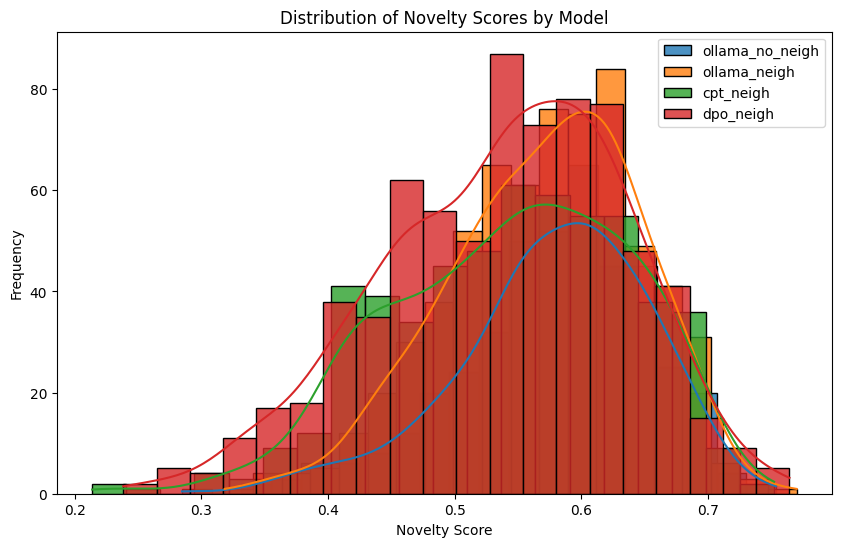

In [128]:
# plotando distribuições em conjunto
plt.figure(figsize=(10, 6))
for model_name, novelty_scores in model_novelties.items():
    sns.histplot(x=novelty_scores, label=model_name, alpha=0.8, bins=20, kde=True)
plt.xlabel("Novelty Score")
plt.ylabel("Frequency")
plt.title("Distribution of Novelty Scores by Model")
plt.legend()

In [130]:
# criando um dataframe novo e organizando dados para vis
novelty_values = []
for model_name, novelty_scores in model_novelties.items():
    for score in novelty_scores:
        novelty_values.append({
            "model": model_name,
            "novelty_score": score
        })
novelty_df = pd.DataFrame(novelty_values)

Text(0.5, 1.0, 'Comparison of Novelty Scores by Model')

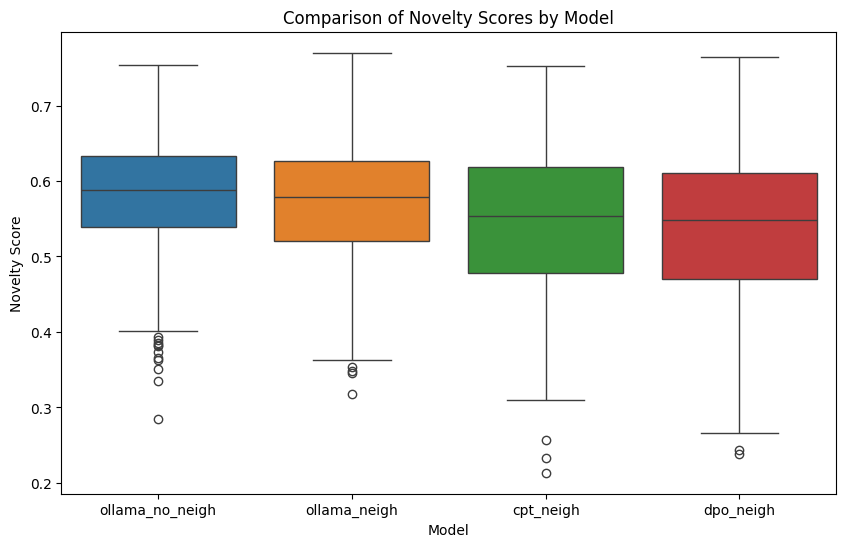

In [132]:
# visualizando boxplot para comparar a novidade dos modelos
plt.figure(figsize=(10, 6))
sns.boxplot(x="model", y="novelty_score", data=novelty_df, hue="model", dodge=False)
plt.xlabel("Model")
plt.ylabel("Novelty Score")
plt.title("Comparison of Novelty Scores by Model")